# Correlations

In [1]:
import pickle
import torch
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## Read in data

In [2]:
# Infectivity
mutation_file = 'results/mutation_infectivity_effects.csv'
infectivity = pd.read_csv(mutation_file)

In [3]:
# Neutralization
neutralization_file = 'results/mutation_neutralization_effects.csv'
neutralization = pd.read_csv(neutralization_file)

In [4]:
# PyR0
pyro_file = 'data/PyR0/2023-09-19/mutations.tsv'
pyro = pd.read_csv(pyro_file, sep='\t', usecols=['mutation', 'R / R_A', 'R / R_A 95% ci lower', 'R / R_A 95% ci upper']).rename(columns={'mutation':'Mutation'})
pyro = pyro[pyro['Mutation'].str.startswith('S:')]
pyro['Mutation'] = pyro['Mutation'].apply(lambda x: x[2:])

In [5]:
# BVAS
bvas_file = 'data/BVAS/2023-09-20/allele_summary.csv'
bvas = pd.read_csv(bvas_file).rename(columns={'Unnamed: 0':'Mutation'}).drop(columns='Rank')
bvas = bvas[bvas['Mutation'].str.startswith('S:')]
bvas['Mutation'] = bvas['Mutation'].apply(lambda x: x[2:])

In [6]:
# Join
df = pd.DataFrame()
df = pd.merge(infectivity, neutralization, on='Mutation', suffixes=[' Infectivity', ' Neutralization'])
df = pd.merge(df, pyro, on='Mutation', suffixes=['', ''])
df = pd.merge(df, bvas, on='Mutation', suffixes=['', ''])
df = df.rename(columns={'R / R_A':'R / R_A (PyR0)', 'PIP':'PIP (BVAS)', 'Beta':'Beta (BVAS)'})
df

,Mutation,Mean Infectivity,Std Infectivity,Pool,Mean Neutralization,Std Neutralization,R / R_A (PyR0),R / R_A 95% ci lower,R / R_A 95% ci upper,PIP (BVAS),Beta (BVAS),BetaStd,ConditionalBeta,ConditionalBetaStd
0,V213G,0.317030,0.461729,Bi-valent Boost,0.594796,0.193595,1.05707,1.05703,1.05711,0.012438,-0.000046,0.009131,-0.006068,0.105169
1,V213G,0.317030,0.461729,Vac_Pfiz-2,0.507568,0.214496,1.05707,1.05703,1.05711,0.012438,-0.000046,0.009131,-0.006068,0.105169
2,V213G,0.317030,0.461729,Conv_Delta,0.460210,0.191466,1.05707,1.05703,1.05711,0.012438,-0.000046,0.009131,-0.006068,0.105169
3,V213G,0.317030,0.461729,BTI_BA.1-3,0.414693,0.204149,1.05707,1.05703,1.05711,0.012438,-0.000046,0.009131,-0.006068,0.105169
4,V213G,0.317030,0.461729,Vac_Mod-1,0.373135,0.218365,1.05707,1.05703,1.05711,0.012438,-0.000046,0.009131,-0.006068,0.105169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,L452R,-0.590647,0.272314,BTI_BA.1-2,-0.395832,0.132220,1.17672,1.17653,1.17691,1.000000,0.510087,0.041544,0.510087,0.041544
203,L452R,-0.590647,0.272314,Boost_Mod-1,-0.444573,0.128408,1.17672,1.17653,1.17691,1.000000,0.510087,0.041544,0.510087,0.041544
204,L452R,-0.590647,0.272314,Boost_Pfiz-1,-0.482041,0.123891,1.17672,1.17653,1.17691,1.000000,0.510087,0.041544,0.510087,0.041544
205,L452R,-0.590647,0.272314,Boost_Pfiz-2,-0.568123,0.125869,1.17672,1.17653,1.17691,1.000000,0.510087,0.041544,0.510087,0.041544


## Compare

In [7]:
df[['Mean Infectivity', 'Mean Neutralization', 'R / R_A (PyR0)', 'Beta (BVAS)', 'PIP (BVAS)']].corr()

,Mean Infectivity,Mean Neutralization,R / R_A (PyR0),Beta (BVAS),PIP (BVAS)
Mean Infectivity,1.000000,0.011656,-0.467889,-0.224257,0.151474
Mean Neutralization,0.011656,1.000000,0.337879,-0.018219,-0.258778
R / R_A (PyR0),-0.467889,0.337879,1.000000,0.363702,-0.353771
Beta (BVAS),-0.224257,-0.018219,0.363702,1.000000,0.194167
PIP (BVAS),0.151474,-0.258778,-0.353771,0.194167,1.000000


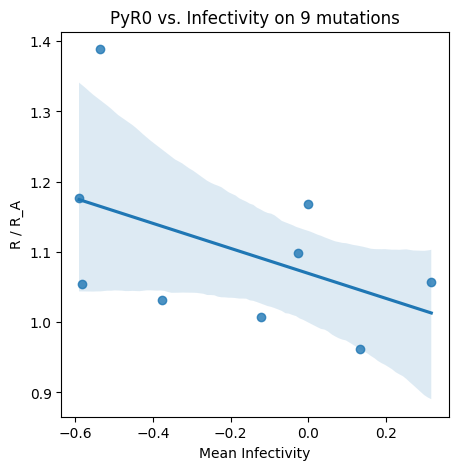

In [35]:
# Infectivity vs PyR0
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='R / R_A',
            data=pd.merge(infectivity, pyro, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            ax=ax);

pyro_muts = set(pyro.Mutation)
inf_muts = set(infectivity.Mutation)

ax.set_title('PyR0 vs. Infectivity on {} mutations'.format(len(pyro_muts&inf_muts)));

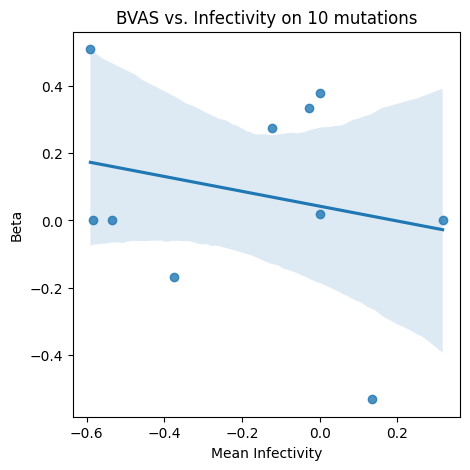

In [34]:
# Infectivity vs BVAS Beta
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Infectivity',
            y='Beta',
            data=pd.merge(infectivity, bvas, on='Mutation').rename(columns={'Mean':'Mean Infectivity'}),
            ax=ax);

bvas_muts = set(bvas.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('BVAS vs. Infectivity on {} mutations'.format(len(bvas_muts&neut_muts)));

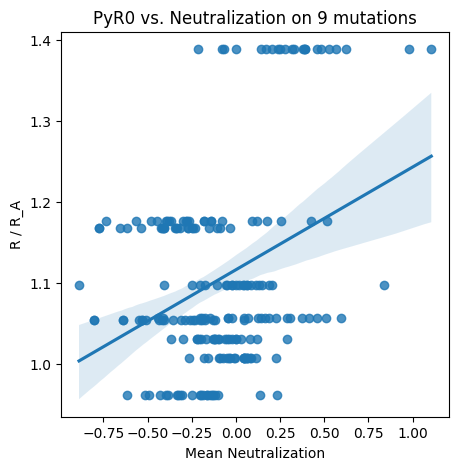

In [40]:
# Neutralization vs PyR0
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='R / R_A',
            data=pd.merge(neutralization, pyro, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            ax=ax);

pyro_muts = set(pyro.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('PyR0 vs. Neutralization on {} mutations'.format(len(pyro_muts&neut_muts)));

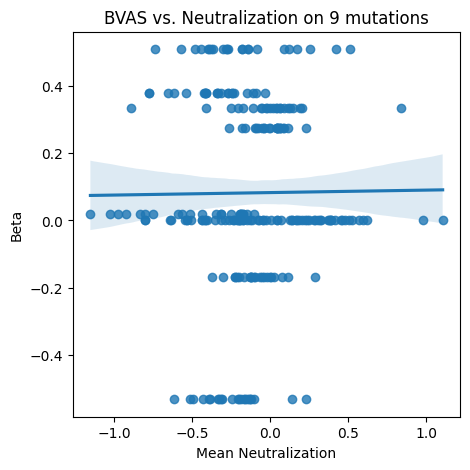

In [41]:
# Neutralization vs BVAS
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='Beta',
            data=pd.merge(neutralization, bvas, on='Mutation').rename(columns={'Mean':'Mean Neutralization'}),
            ax=ax);

bvas_muts = set(bvas.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('BVAS vs. Neutralization on {} mutations'.format(len(pyro_muts&neut_muts)));

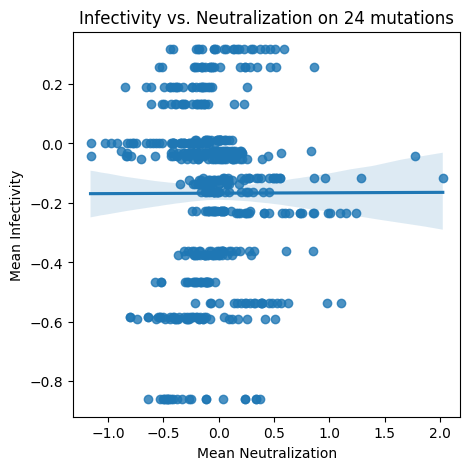

In [42]:
# Neutralization vs Infectivity
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(x='Mean Neutralization',
            y='Mean Infectivity',
            data=pd.merge(neutralization, infectivity, on='Mutation', suffixes = [' Neutralization', ' Infectivity']),
            ax=ax);

inf_muts = set(infectivity.Mutation)
neut_muts = set(neutralization.Mutation)

ax.set_title('Infectivity vs. Neutralization on {} mutations'.format(len(inf_muts&neut_muts)));